# Classification: CNN
- Used Pytorch pre trained ResNet-18
- Replace last layer for binary classification
- Used same '30kds' as YOLO, ViT (same data for training to later compare models)
- Resizes images to 224x224px as expected by the ResNet
- Runs on gpu/cpu

In [ ]:
# Run 'create_30k_ds.py' to create a balanced distribution (YOLO structure).
# This dataset has 30k real images and 30k fake images
# Split is 80% train, 10% test and 10% valid
# Structure:
'''
30kds/
│── train/
│   ├── Real/   (80% of real images)
│   ├── Fake/   (80% of selected fake images)
│
│── val/
│   ├── Real/   (10% of real images)
│   ├── Fake/   (10% of selected fake images)
│
│── test/
│   ├── Real/   (10% of real images)
│   ├── Fake/   (10% of selected fake images)
'''

In [1]:
import os
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm
import time
import random
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATASET_PATH = "30kds"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = ImageFolder(root=TRAIN_PATH, transform=transform)
val_dataset = ImageFolder(root=VAL_PATH, transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [ ]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features  # Get input features for the last layer
model.fc = nn.Linear(num_ftrs, 2)  # Modify the final layer for binary classification
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

epochs = 50
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix(loss=f"{running_loss/len(train_loader):.4f}")

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(train_loader):.4f}")

os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/resnet_classifier.pth")
print("Training complete. Model saved.")

c:\Users\danie\anaconda3\envs\DL\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\danie\anaconda3\envs\DL\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50] - Loss: 0.4662


Epoch [2/50] - Loss: 0.3133


Epoch [3/50] - Loss: 0.2333


Epoch [4/50] - Loss: 0.1704


...

Epoch [46/50] - Loss: 0.0064


Epoch [47/50] - Loss: 0.0082


Epoch [48/50] - Loss: 0.0080


Epoch [49/50] - Loss: 0.0061


Epoch [50/50] - Loss: 0.0070
Training complete. Model saved.


In [5]:
def evaluate_model(model_path, val_loader):
    """Evaluates model accuracy on the validation set."""
    model = models.resnet18(pretrained=False)  # Load ResNet without pretrained weights
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)  # Set binary classification output

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")

# Run evaluation
evaluate_model("models/resnet_classifier.pth", val_loader)


Validation Accuracy: 98.43%


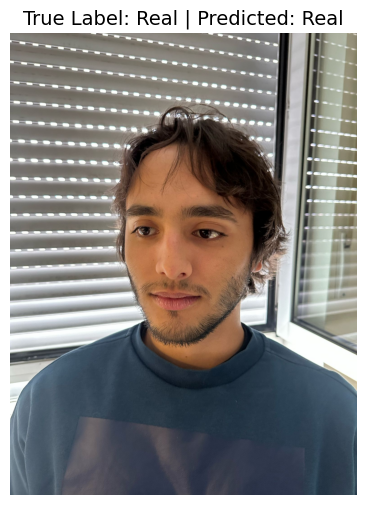

In [6]:
def classify_folder(model_path, folder_path, interval=2):
    """Classifies all images in a folder using a ResNet model and displays predictions."""
    
    model = models.resnet18(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),  
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    class_labels = train_dataset.classes  # Ensure correct label order
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(image_files)

    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        img = Image.open(image_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            predicted_class = torch.argmax(output, dim=1).item()

        predicted_label = class_labels[predicted_class]

        real_label = "Unknown"
        for class_name in class_labels:
            if class_name.lower() in image_file.lower():
                real_label = class_name
                break

        clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"True Label: {real_label} | Predicted: {predicted_label}", fontsize=14)
        plt.axis("off")
        display(plt.gcf())
        plt.close()

        time.sleep(interval)

# Run classification visualization
classify_folder("models/resnet_classifier.pth", "class_test")
